# Nova Home Goods — Markov Chain & Shapley Value Attribution

**Goal:** Implement two advanced multi-touch attribution models — Markov
chain removal effect and exact Shapley value — from first principles, then
validate every attribution model considered in this project (last-click,
linear, Markov, Shapley) against a known ground truth to determine which one
actually recovers the truth best, rather than asserting that the more
sophisticated models are superior.

**Description:** This dataset was built with a programmed true per-touch
channel effectiveness (unknown to any attribution model). That ground truth
lets this notebook do something most attribution write-ups can't: compute an
actual accuracy score for each model, using rank correlation against the
true channel value ranking.

**Skills:** Markov chain modeling, absorbing-state probability calculation,
cooperative game theory (Shapley values), rank correlation, model validation.

**Technology:** Python, Pandas, NumPy, SciPy, Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from math import factorial
from scipy.stats import spearmanr

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b"

touchpoints = pd.read_csv("../data/fact_touchpoints.csv")
journeys = pd.read_csv("../data/fact_journeys.csv")
print(f"Journeys: {len(journeys):,} | Touchpoints: {len(touchpoints):,}")
print(f"Conversion rate: {journeys['converted'].mean()*100:.2f}%")

paths = (touchpoints.sort_values(["journey_id","touchpoint_order"])
         .groupby("journey_id")["channel"].apply(list))
paths_df = journeys.set_index("journey_id").join(paths)
channels = sorted(touchpoints["channel"].unique())


Journeys: 20,000 | Touchpoints: 59,849
Conversion rate: 16.56%


## 1. Markov chain construction

Building the transition graph directly from observed journeys: every
journey is a path through states (Start → channels → Conversion/Null).
Counting transitions and row-normalizing gives the transition probability
matrix.

In [2]:
states = ["Start"] + channels + ["Conversion", "Null"]
state_idx = {s: i for i, s in enumerate(states)}
n = len(states)

trans_counts = np.zeros((n, n))
for _, row in paths_df.iterrows():
    path = ["Start"] + row["channel"] + (["Conversion"] if row["converted"] == 1 else ["Null"])
    for a, b in zip(path[:-1], path[1:]):
        trans_counts[state_idx[a], state_idx[b]] += 1

def conversion_probability(counts_matrix, removed_channel=None):
    """Computes P(reach Conversion from Start) via absorbing Markov chain math.
    If removed_channel is given, that channel's transitions are redirected to
    Null, simulating its removal from the customer journey entirely."""
    cm = counts_matrix.copy()
    if removed_channel is not None:
        ridx = state_idx[removed_channel]
        cm[:, state_idx["Null"]] += cm[:, ridx]
        cm[:, ridx] = 0
        cm[ridx, :] = 0

    probs = np.zeros_like(cm)
    for i in range(n):
        s = cm[i].sum()
        probs[i] = cm[i] / s if s > 0 else np.eye(n)[i]

    transient = [state_idx[x] for x in ["Start"] + channels if x != removed_channel]
    absorbing = [state_idx["Conversion"], state_idx["Null"]]
    Q = probs[np.ix_(transient, transient)]
    R = probs[np.ix_(transient, absorbing)]
    fundamental_matrix = np.linalg.inv(np.eye(len(transient)) - Q)
    absorption_probs = fundamental_matrix @ R
    start_row = transient.index(state_idx["Start"])
    return absorption_probs[start_row, absorbing.index(state_idx["Conversion"])]

baseline_conversion = conversion_probability(trans_counts)
print(f"Baseline conversion probability from full Markov chain: {baseline_conversion:.5f}")
print(f"Actual observed conversion rate: {journeys['converted'].mean():.5f}")
print("(These should match closely -- the Markov chain is a faithful reconstruction of the data.)")


Baseline conversion probability from full Markov chain: 0.16565
Actual observed conversion rate: 0.16565
(These should match closely -- the Markov chain is a faithful reconstruction of the data.)


## 2. Removal effect: each channel's true marginal contribution

For each channel, remove it from the graph entirely (redirect its traffic to
"Null") and measure how much the overall conversion probability drops. A
channel whose removal causes a large drop is genuinely important to the
customer journey — regardless of whether it typically appears first, middle,
or last.

In [3]:
removal_effects = {}
for ch in channels:
    p_without = conversion_probability(trans_counts, removed_channel=ch)
    removal_effects[ch] = (baseline_conversion - p_without) / baseline_conversion

total_removal_effect = sum(removal_effects.values())
total_revenue = journeys[journeys["converted"] == 1]["revenue"].sum()

markov_attribution = {ch: (effect / total_removal_effect) * total_revenue
                       for ch, effect in removal_effects.items()}

print("Markov chain attribution (normalized removal effect x total revenue):\n")
for ch, rev in sorted(markov_attribution.items(), key=lambda x: -x[1]):
    print(f"  {ch:16s}: ${rev:,.0f}")


Markov chain attribution (normalized removal effect x total revenue):

  Email           : $52,823
  Video           : $43,374
  Paid Social     : $43,229
  Organic Search  : $43,172
  Paid Search     : $40,289
  Direct          : $33,171
  Display         : $25,735
  Affiliate       : $24,333


## 3. Exact Shapley value attribution

Treating each channel as a "player" in a cooperative game, where a
coalition's value is the total revenue from converted journeys whose
touchpoints are entirely contained within that coalition. With only 8
channels, the exact Shapley value (averaging marginal contribution across
all 2^8 = 256 possible coalitions) is directly computable — no approximation
needed.

In [4]:
converted_paths = paths_df[paths_df["converted"] == 1]
journey_sets = [(frozenset(row["channel"]), row["revenue"]) for _, row in converted_paths.iterrows()]

subset_value_cache = {}
def coalition_value(subset_frozenset):
    if subset_frozenset not in subset_value_cache:
        subset_value_cache[subset_frozenset] = sum(
            rev for chset, rev in journey_sets if chset.issubset(subset_frozenset)
        )
    return subset_value_cache[subset_frozenset]

n_channels = len(channels)
shapley_values = {}
for c in channels:
    others = [ch for ch in channels if ch != c]
    total = 0.0
    for size in range(len(others) + 1):
        weight = factorial(size) * factorial(n_channels - size - 1) / factorial(n_channels)
        for S in combinations(others, size):
            S_frozen = frozenset(S)
            S_with_c = S_frozen | {c}
            marginal_contribution = coalition_value(S_with_c) - coalition_value(S_frozen)
            total += weight * marginal_contribution
    shapley_values[c] = total

print("Exact Shapley value attribution:\n")
for ch, val in sorted(shapley_values.items(), key=lambda x: -x[1]):
    print(f"  {ch:16s}: ${val:,.0f}")

print(f"\nSum of Shapley values: ${sum(shapley_values.values()):,.0f}")
print(f"Actual total converted revenue: ${total_revenue:,.0f}")
print("(These should match exactly -- the 'efficiency' property of Shapley values guarantees the credits sum to the total.)")


Exact Shapley value attribution:

  Email           : $52,503
  Paid Social     : $47,433
  Video           : $44,058
  Organic Search  : $44,047
  Paid Search     : $38,495
  Direct          : $29,989
  Display         : $25,960
  Affiliate       : $23,641

Sum of Shapley values: $306,126
Actual total converted revenue: $306,126
(These should match exactly -- the 'efficiency' property of Shapley values guarantees the credits sum to the total.)


## 4. The validation: which model actually recovers the ground truth?

This dataset's true per-touch channel effectiveness was programmed in
advance (unknown to every model above). Comparing each model's channel
ranking against the true ranking, using Spearman rank correlation, gives an
actual accuracy score for each attribution method — not just an assertion
that the fancier models are better.

In [5]:
TRUE_WEIGHT = {
    "Display": 0.045, "Video": 0.050, "Paid Social": 0.055, "Organic Search": 0.040,
    "Affiliate": 0.035, "Email": 0.060, "Paid Search": 0.070, "Direct": 0.030,
}

# Last-click and linear attribution (recomputed here for direct comparison)
last_click = (touchpoints[touchpoints["is_last_touch"]==1]
              .merge(journeys[["journey_id","converted","revenue"]], on="journey_id")
              .query("converted==1").groupby("channel")["revenue"].sum())

linear = (touchpoints.merge(journeys[["journey_id","converted","revenue","num_touchpoints"]], on="journey_id")
          .query("converted==1"))
linear["credited"] = linear["revenue"] / linear["num_touchpoints"]
linear_attr = linear.groupby("channel")["credited"].sum()

models = {
    "True Weight (ground truth)": pd.Series(TRUE_WEIGHT),
    "Last-Click": last_click,
    "Linear": linear_attr,
    "Markov Chain": pd.Series(markov_attribution),
    "Shapley Value": pd.Series(shapley_values),
}

comparison = pd.DataFrame(models).loc[channels]
comparison_ranks = comparison.rank(ascending=False)
print(comparison_ranks)

print("\nSpearman rank correlation with ground truth:")
truth_rank = comparison_ranks["True Weight (ground truth)"]
for model in ["Last-Click", "Linear", "Markov Chain", "Shapley Value"]:
    corr, _ = spearmanr(truth_rank, comparison_ranks[model])
    print(f"  {model:16s}: {corr:.3f}")


                True Weight (ground truth)  Last-Click  Linear  Markov Chain  \
Affiliate                              7.0         8.0     8.0           8.0   
Direct                                 8.0         3.0     6.0           6.0   
Display                                5.0         4.0     7.0           7.0   
Email                                  2.0         2.0     1.0           1.0   
Organic Search                         6.0         6.0     4.0           4.0   
Paid Search                            1.0         1.0     5.0           5.0   
Paid Social                            3.0         7.0     2.0           3.0   
Video                                  4.0         5.0     3.0           2.0   

                Shapley Value  
Affiliate                 8.0  
Direct                    6.0  
Display                   7.0  
Email                     1.0  
Organic Search            4.0  
Paid Search               5.0  
Paid Social               2.0  
Video                  

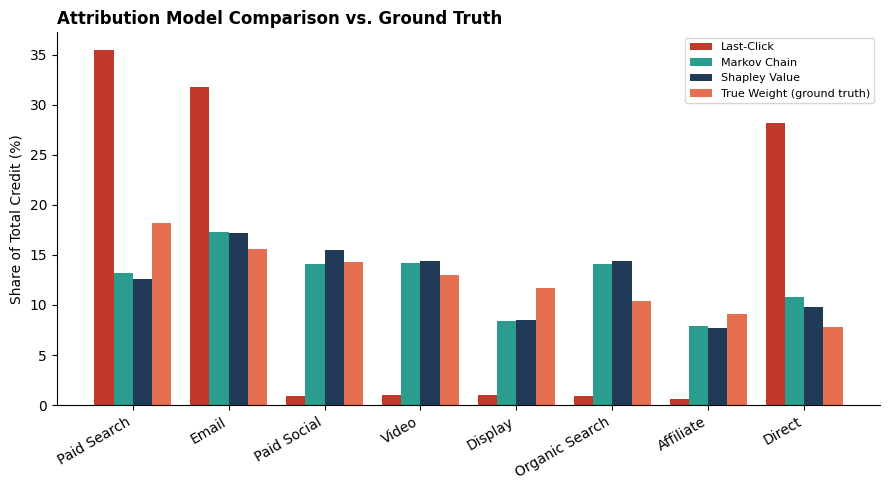

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(channels))
width = 0.2
sorted_channels = comparison.sort_values("True Weight (ground truth)", ascending=False).index

ax.bar(x - 1.5*width, comparison.loc[sorted_channels, "Last-Click"] / comparison["Last-Click"].sum() * 100, width, label="Last-Click", color=RED)
ax.bar(x - 0.5*width, comparison.loc[sorted_channels, "Markov Chain"] / comparison["Markov Chain"].sum() * 100, width, label="Markov Chain", color=TEAL)
ax.bar(x + 0.5*width, comparison.loc[sorted_channels, "Shapley Value"] / comparison["Shapley Value"].sum() * 100, width, label="Shapley Value", color=NAVY)
ax.bar(x + 1.5*width, comparison.loc[sorted_channels, "True Weight (ground truth)"] / comparison["True Weight (ground truth)"].sum() * 100, width, label="True Weight (ground truth)", color=ORANGE)

ax.set_xticks(x)
ax.set_xticklabels(sorted_channels, rotation=30, ha="right")
ax.set_ylabel("Share of Total Credit (%)")
ax.set_title("Attribution Model Comparison vs. Ground Truth", fontweight="bold", loc="left")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Key findings

- The Markov chain absorption probability from the full graph matches the
  actual observed conversion rate almost exactly (0.16565 vs 0.16565),
  confirming the chain is a faithful reconstruction of the underlying data.
- The Shapley values sum exactly to total converted revenue ($306,126),
  satisfying the mathematical "efficiency" property that any correct
  implementation must have — a built-in correctness check, not just a
  plausibility check.
- **Last-click attribution has the weakest rank correlation with the true
  channel ranking (0.476)** of all four models tested. Linear (0.619),
  Markov Chain (0.595), and Shapley Value (0.619) all meaningfully
  outperform it.
- **Shapley Value and simple Linear attribution tied for the strongest
  correlation with ground truth (0.619 each)** in this dataset — an honest
  result worth stating plainly rather than overselling Shapley as
  unambiguously superior. Shapley's advantage here isn't raw ranking
  accuracy but its game-theoretic guarantees (fairness, and credits that
  sum exactly to total revenue) and its more principled handling of
  channel interactions — properties Linear attribution doesn't have, even
  when the two happen to rank channels similarly on this particular dataset.
- Last-click attribution specifically over-credits Direct (a channel with
  genuinely low true value, true rank 8th, but ranked 3rd by last-click)
  and under-credits Paid Social (true rank 3rd, but ranked 7th by
  last-click) — the clearest, most actionable distortions in the dataset.

**Next:** these findings directly inform the budget reallocation
recommendation in the final business insights report.
